## 0 — Imports & Setup

In [1]:
import sys, os, numpy as np, torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
sys.path.append('.')   # adjust if your scripts live in a subfolder
from utils.engine import train_model, evaluate

from config import DEVICE, CHECKPOINT_DIR, EPOCHS
from utils.dataloader import get_dataloaders
from models.vgg import VGG16

# get train/val loaders and class names from the existing dataset
train_loader, val_loader, test_loader, class_names = get_dataloaders()
print(f'Dataset loaded successfully with {len(class_names)} classes: {class_names}')

Train images : 1000
Val images   : 36
Test images  : 38
Classes      : ['Angry', 'Other', 'Sad', 'happy']
Dataset loaded successfully with 4 classes: ['Angry', 'Other', 'Sad', 'happy']


## 1 — Train If Needed / Load VGG16 Checkpoint

In [2]:
vgg = VGG16().to(DEVICE)
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'VGG16.pth')

if os.path.exists(checkpoint_path):
    vgg.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    vgg.eval()
    print(f'VGG16 loaded from {checkpoint_path}')
else:
    print(f'No checkpoint found at {checkpoint_path}. Training VGG16 first...')
    vgg, best_acc = train_model(vgg, 'VGG16', train_loader, val_loader, class_names, epochs=EPOCHS,patience=8)
    vgg.eval()
    print(f'VGG16 trained and saved to {checkpoint_path} with best val acc {best_acc:.4f}')

No checkpoint found at c:\Users\alyad\Desktop\lab4\checkpoints\VGG16.pth. Training VGG16 first...

  Training : VGG16  |  device: cpu
Epoch [ 1/30]  Train Loss: 2.3901  Train Acc: 0.3350  |  Val Loss: 1.3596  Val Acc: 0.3889
  Model saved with Val Acc: 0.3889
Epoch [ 2/30]  Train Loss: 1.1340  Train Acc: 0.5120  |  Val Loss: 1.5209  Val Acc: 0.4722
  Model saved with Val Acc: 0.4722
  EarlyStopping: no improvement for 1/8 epochs
Epoch [ 3/30]  Train Loss: 0.9657  Train Acc: 0.6070  |  Val Loss: 1.2908  Val Acc: 0.5000
  Model saved with Val Acc: 0.5000
Epoch [ 4/30]  Train Loss: 0.8336  Train Acc: 0.6810  |  Val Loss: 1.5760  Val Acc: 0.5833
  Model saved with Val Acc: 0.5833
  EarlyStopping: no improvement for 1/8 epochs
Epoch [ 5/30]  Train Loss: 0.7336  Train Acc: 0.7230  |  Val Loss: 1.8397  Val Acc: 0.5000
  EarlyStopping: no improvement for 2/8 epochs
Epoch [ 6/30]  Train Loss: 0.6315  Train Acc: 0.7570  |  Val Loss: 1.7702  Val Acc: 0.4722
  EarlyStopping: no improvement for 3/8

## 2 — Run Inference

In [3]:
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        preds = vgg(images.to(DEVICE)).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f'Val Accuracy: {(all_preds == all_labels).mean():.4f}')

Val Accuracy: 0.5000


## 3 — Confusion Matrix

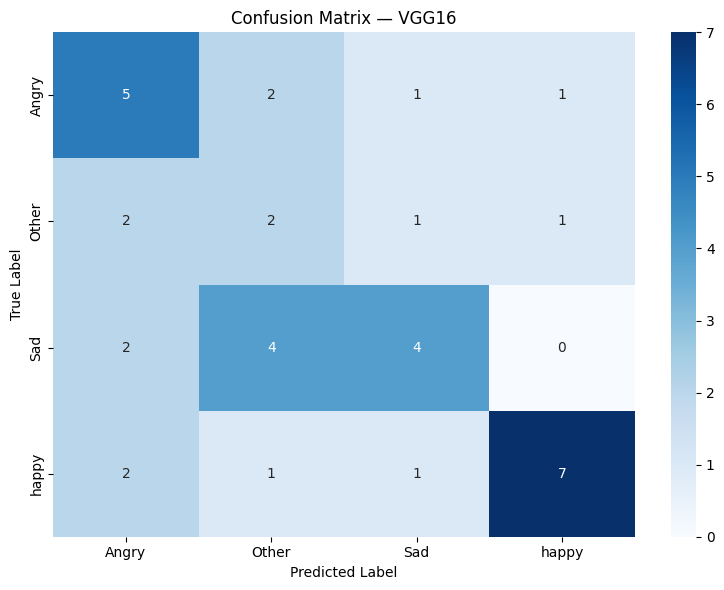

In [4]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — VGG16')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

## 4 — Per-Class Precision / Recall / F1

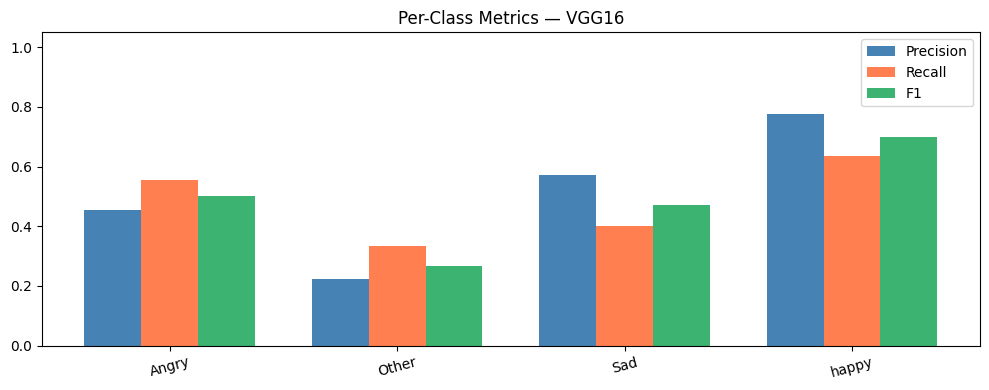

              precision    recall  f1-score   support

       Angry     0.4545    0.5556    0.5000         9
       Other     0.2222    0.3333    0.2667         6
         Sad     0.5714    0.4000    0.4706        10
       happy     0.7778    0.6364    0.7000        11

    accuracy                         0.5000        36
   macro avg     0.5065    0.4813    0.4843        36
weighted avg     0.5471    0.5000    0.5141        36



In [5]:
p, r, f, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)

x = np.arange(len(class_names)); w = 0.25
plt.figure(figsize=(10, 4))
plt.bar(x - w, p, w, label='Precision', color='steelblue')
plt.bar(x,     r, w, label='Recall',    color='coral')
plt.bar(x + w, f, w, label='F1',        color='mediumseagreen')
plt.xticks(x, class_names, rotation=15)
plt.ylim(0, 1.05)
plt.title('Per-Class Metrics — VGG16')
plt.legend(); plt.tight_layout(); plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4))

## 5 — Training Curves

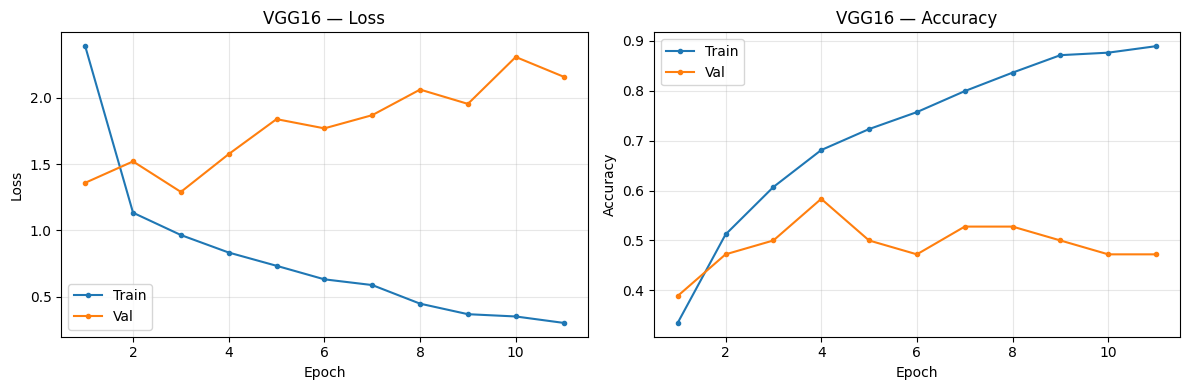

In [6]:
# Load history saved during training, or paste your lists manually
history_path = os.path.join(CHECKPOINT_DIR, 'VGG16_history.pt')
if not os.path.exists(history_path):
    raise FileNotFoundError(
        f'History file not found at {history_path}. Train with train_model first.'
    )
history = torch.load(history_path, map_location=DEVICE)

epochs = range(1, len(history['train_acc']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='Train', marker='o', markersize=3)
ax1.plot(epochs, history['val_loss'],   label='Val',   marker='o', markersize=3)
ax1.set_title('VGG16 — Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], label='Train', marker='o', markersize=3)
ax2.plot(epochs, history['val_acc'],   label='Val',   marker='o', markersize=3)
ax2.set_title('VGG16 — Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [7]:
import os
for cls in os.listdir('dataset/train'):
    count = len(os.listdir(f'dataset/train/{cls}'))
    print(f'{cls}: {count}')

Angry: 250
happy: 250
Other: 250
Sad: 250
